Randomised Riemannian Hamiltonian Monte Carlo for Bayesian Estimation as a Constrained Distribution Problem

Defined by $g(X,d_{1},d_{2}) = X^{T}X - \mathbb{I}_{p} = 0$, we have $\mathcal{M} := \{(X,d_1 , d_2 ) \in \mathbb{R}^{d \times p}\times \mathbb{R}^{p} \times \mathbb{R}^d \mid g(X) = 0\}$

For $A \in \mathbb{R}^{d \times p}$ with $v_{i} \in \mathbb{R}^{d}$, $i = 1,...,p$ being the column vectors. We define $g_{ij}(A) = v_{i} \cdot v_{j} - \delta_{ij} = 0$


1) Dynamics

In [1]:
import numba
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random

# Data Extraction

In [2]:
import os
from os import sys

In [3]:
data_matrix = np.zeros((120,2000))


for k in range(1,2001):
    file_location = './cov_shrink_simulations/'
    if k < 10:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
    
    if 10 <= k < 100:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2              =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
        
    if 100 <= k < 1000:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    if 1000 <= k:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    temp12  = np.append(temp1, temp2, axis = 0)
    temp123 = np.append(temp12,temp3, axis = 0)
    #print(np.shape(temp123))
    data_matrix[:,k-1]  = np.reshape(temp123,(len(temp123),))
        


In [4]:
# Astronomical Data
#n = 2000
N = 120
N = 60

p =  N//6
d =  N
m =  p

In [5]:
n = N*2//3
Data = data_matrix[:N,:2000]

mean = np.mean(Data[:,:n],axis = 1)
var = np.var(Data[:,:n],axis = 1)

    
    
for i in range(2000):
    Data[:,i] -= mean
    Data[:,i] /= np.sqrt(var)


In [6]:
# np.max(Data)

In [7]:
# np.min(Data)

In [8]:
# np.mean(Data,axis = 1)

In [9]:
mean = np.mean(Data[:,:n],axis = 1)

# Data_matrix_2 = np.zeros((N,n))

# for i in range(N):
#     Data_matrix_2[i,:] = Data_matrix_2[i,:] - mean[i]
    
# maximum = np.max(abs(Data_matrix_2))
# print(maximum)

We are sampling from the von Mises-Fisher distribution which has density given by 

$p_{vMF}(X) \propto \exp{(\langle f_{1},x_{1} \rangle + ... + \langle f_{p},x_{p}\rangle)}$

In [10]:

#print(np.mean(abs(np.random.normal(0,1,2000))))

# Preconditioning

[-3.57136196e-16  1.49186219e-16  1.80411242e-16 -3.40005801e-16
 -9.36750677e-17  2.77555756e-16  1.01047642e-16  1.80411242e-16
  3.31332184e-16  2.60208521e-16  1.50920942e-16 -6.59194921e-17
  0.00000000e+00 -6.93889390e-17 -4.16333634e-17  5.55111512e-17
 -1.04083409e-17  2.42861287e-17 -1.11022302e-16  4.16333634e-17
  1.38777878e-17  0.00000000e+00 -1.04083409e-17  2.01227923e-16
 -2.60208521e-18  6.93889390e-17 -6.59194921e-17  7.63278329e-17
  2.22044605e-16  3.57353036e-16  1.64798730e-17 -9.71445147e-17
  6.93889390e-17 -1.83880688e-16  1.30971622e-16 -4.05925293e-16
 -2.02312125e-16 -1.40512602e-16 -1.33573708e-16 -3.20923843e-17
  5.68989300e-16  1.63064007e-16  2.22044605e-16  1.17961196e-16
  2.15105711e-16  9.02056208e-17 -2.77555756e-16  1.38777878e-17
 -4.09394740e-16  9.71445147e-17  2.08166817e-17  4.07660017e-16
  1.94289029e-16 -4.16333634e-17  3.12250226e-17  4.16333634e-17
  3.12250226e-17 -1.99493200e-17  8.83624771e-18  4.85722573e-17]


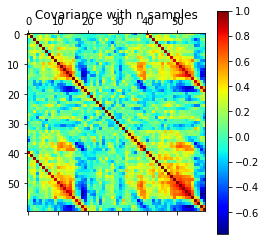

In [11]:
# sample variance
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n
    
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

print(mean2)

plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [12]:
D_2 = np.diag(np.diag(S_small))
Pmat = (S_small - D_2)


EIG = np.linalg.eig(Pmat)
A  = np.zeros((d,p))
for i in range(p):
    A[:,i] = EIG[1][:,i]



D_1 = np.diag(EIG[0][:p])

Approx = np.matmul(A,np.matmul(D_1,np.transpose(A)))
D_2 = np.diag(np.diag(S_small)) - np.diag(np.diag(Approx))
Approx += D_2

# Sampling

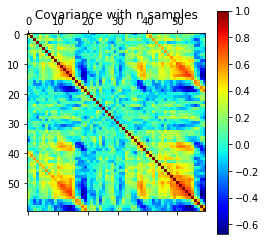

In [13]:
    
plt.matshow(Approx,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [14]:
#p<=d



p =  N//6
d =  N
m =  p


dimension = int(d*p+p+d)
num_of_constraints  = int(p*(p+1)/2)

σ_1 = 2
σ_2 = 2
#Matrix in distribution

@numba.jit(nopython=True)
def vec_to_matrix(q):
    X = np.zeros((d,p))
    for i in range(d):
        for j in range(p):
            X[i,j] = q[j*d+i]
    return X

@numba.jit(nopython=True)
def matrix_to_vec(X):
    #initialising filler array
    x = np.zeros(d*p)
    
    for i in range(d*p):
        i_index = i%d
        j_index =  int((i - i_index)/d)
        x[i] = X[i_index,j_index]
    return x

@numba.jit(nopython=True)
def dot_product(v1,v2):
    dot = 0
    for i in range(len(v1)):
        
        dot += v1[i]*v2[i]
        
    return dot

@numba.jit(nopython=True)
def matmul(matrix1,matrix2):
    a = matrix1.shape[0]
    b = matrix2.shape[1]
    c = matrix2.shape[0]
    rmatrix = np.zeros((a,b))
    for i in range(a):
        for j in range(b):
            for k in range(c):
                rmatrix[i,j] += matrix1[i,k] * matrix2[k,j]
    return rmatrix

@numba.jit(nopython=True)
def matrix_vec_multiplication(A,x):
    v = np.zeros(len(A))
    
    for i in range(len(A)):
        for j in range(len(x)):
                v[i] += A[i][j] * x[j]
    return v


@numba.jit(nopython=True)
def g_ij(q,i,j):
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    if i==j:
        y = np.linalg.norm(X[:,i])**2 - 1
    else:
        y = dot_product(X[:,i],X[:,j])
        
    return y


@numba.jit(nopython=True)
def G(q): #considering i<j.
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    z = np.zeros((dimension,num_of_constraints))
    
    for i in range(p): #block diagonals
        z[d*i:d*(i+1),int(p*i-0.5*i*(i-1)):int(p*(i+1) - 0.5*i*(i+1))] = X[:,i:]
    
        #vector diagonals
        for j in range(p-i):
            z[(j+i)*d:(j+i+1)*d,int(p*i-0.5*i*(i-1) + j)] += X[:,i]  
    z = z.T #could implement this above
    return z


In [15]:
@numba.jit(nopython=True)
def potential_derv_fast(q):
    #Can check with numerical differentiation.
    
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    
    Σ_inv_T = np.transpose(np.linalg.inv(Σ))

    #Constructing M
    M_kl = 0.5*n*Σ_inv_T 
    
    for k in range(d):
        for l in range(d):
            for r in range(n):
                M_kl[k,l] -= 0.5*dot_product(Data[:,r]-mean,Σ_inv_T[k,:])*dot_product(Σ_inv_T[:,l],Data[:,r]-mean)
    
    #dUdX
    dUdX = np.zeros((d,p))
    
    for i in range(d):
        
        for j in range(p):
            
            for k in range(d):
                
                for l in range(d):
                    
                    if k == i and l == i:
                        
                        dΣ_kl_dX_ij = 2*X[i,j]*d_1[j]
                        
                    elif k == i:
                        
                        dΣ_kl_dX_ij = d_1[j]*X[l,j]
                        
                    elif l == i:
                        
                        dΣ_kl_dX_ij = X[k,j]*d_1[j]
                    
                    else:
                        continue
                    
                    dUdX[i,j] += M_kl[k,l]*dΣ_kl_dX_ij
                    
                
            
    
    #dUd1
    dUd1 = np.zeros(p)
    
    for j in range(p):
    
        for k in range(d):
                
            for l in range(d): 
                    
                dΣ_kl_dD1_jj = X[k,j]*X[l,j]

                dUd1[j] += M_kl[k,l]*dΣ_kl_dD1_jj

        #adding extra term
        dUd1[j] += d_1[j]/(σ_1)**2
    
   
    #dUd2
    dUd2 = np.zeros(d)
    
    for j in range(d):

        dUd2[j] += M_kl[j,j]*1.
        
        #adding extra term
        dUd2[j] += d_2[j]/(σ_2)**2
    
    pot_derv = np.zeros(int(d*p+p+d))
    pot_derv[:d*p] = matrix_to_vec(dUdX)
    pot_derv[d*p:d*p+p] = dUd1
    pot_derv[d*p+p:] = dUd2
    
    return pot_derv

In [16]:
q_initial = list(matrix_to_vec(np.eye(d,p)))
d_1 = abs(np.random.normal(0,σ_1,p))
d_2 = abs(np.random.normal(0,σ_2,d))
q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
x_init = q_initial
#x_init = q_initial
print(x_init)

[1.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [17]:
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  2.3565855026245117
time after compiling =  0.05631303787231445


In [18]:
#RATTLE Hamiltonian Flow
@numba.jit(nopython=True)
def RATTLE_with_Potential(x0,v0,t,dt,max_elim_iters):
    n = np.floor(t/dt)
    vn = v0
    qn = x0
    vhalf = v0
    G_q = G(qn)
    
    #Gram Matrix is GG^T
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    
    
    pderv = potential_derv_fast(qn)#potential_derv(qn)
    
    residual_list = np.zeros(num_of_constraints)
    for i in range(int(n)):
        
        
        #solver for Lagrange position multipliers
        Q = qn + vn*dt - 0.5*dt*dt*pderv
        
        #non-linear gaussian elimination
        for k in range(max_elim_iters): #i>j
            for i in range(p):
                for j in range(i,p):
                    g_Q = g_ij(Q,i,j)
                    index = int(i*p - 0.5*i*(i-1) + j-i)
                    
                    residual_list[index] = g_Q
                    if abs(g_Q) < 1e-8:
                        continue
                    G_Q = G(Q)
                    
                    #should be sum of i's and js in indexing below
                    dlambda = g_Q/dot_product(G_Q[index,:],G_q[index,:])
                    Q = Q - G_q[index,:]*dlambda
            #break condition
            if np.all(np.abs(residual_list)<1e-8):
                break

        
        #half step
        vhalf = (Q-qn)/dt
        qn = Q
        
        pderv = potential_derv_fast(qn) #potential_derv(qn)
        G_q = G(qn)
        
        gram = matmul(G_q,G_q.T)
        gram_inv = np.linalg.inv(gram)
        
        #linear solver Lagrange velocity multipliers
        b = matrix_vec_multiplication(G_q,2*vhalf/dt - pderv)
        coeffs_v = matrix_vec_multiplication(gram_inv,b)
        
        #full step
        vn = vhalf - 0.5*dt*pderv - 0.5*dt*matrix_vec_multiplication(G_q.T,coeffs_v)
       
    return qn,vn

# Checks

In [19]:
X = np.array([[1,2,3], [4,5,6],[7,8,9]])
#print(X[:,1:])
#g_ij checked
#G checked for what I want.
#print(X.T,X)
M = np.eye(d, p)
M = matrix_to_vec(M)
gram = matmul(G(M),G(M).T)
"G matrix should be #constraints by dimension 0.5*p*(p+1) by p*d" 
#6 by 9
print(gram)
M = np.eye(d, p)


[[4. 0. 0. ... 0. 0. 0.]
 [0. 2. 0. ... 0. 0. 0.]
 [0. 0. 2. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 4. 0. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 0. ... 0. 0. 4.]]


2) Event Time Sampling


In [20]:
#Sampling Event Times
@numba.jit(nopython=True)
def time_exp(lam):
    t = np.random.exponential(lam)
    return t

3) Gaussian Sampling on Tangent Space

In [21]:
@numba.jit(nopython=True)
def tangent_space_gaussian(q):
    
    
    v = np.random.normal(0.,1.0,dimension).T
    
    
    G_q = G(q)
    
    
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    proj_matrix = np.eye(dimension) - matmul(G_q.T,matmul(gram_inv,G_q))
    
    #sample 3d gaussian and then project onto tangent space.
    v = matrix_vec_multiplication(proj_matrix,v)
    
    return v

#check
Z = tangent_space_gaussian(x_init)
T_X = vec_to_matrix(Z[:d*p])  
X = vec_to_matrix(x_init[:d*p])
print('constraint check =',matmul(T_X.T,X) + matmul(X.T,T_X))
print('Should be Gaussian no constraints =',Z[d*p:])

constraint check = [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Should be Gaussian no constraints = [ 0.10564445 -0.11130115 -1.36646606 -0.5989549   0.47748333 -0.57042916
  0.83744687 -0.08433891 -0.77320634 -0.03851302 -0.43733471  0.11123743
 -0.33519137  0.73601549  0.66383203 -0.17909335 -2.34653976 -1.62554657
 -0.89786607 -1.08317064  0.43183698  1.7785466  -0.48510655 -0.19427398
  1.21716049  1.09400123  0.2467076   1.29156364  1.46013683 -1.3570323
 -0.47220429  0.19498282  0.19361692 -0.70278176 -0.03415908  1.29807943
 -0.46168176 -0.55590517  0.9719512   1.5102044   1.40071256  0.28351353
  1.22146335 -0.69120475  0.29000648 -0.42295785 -1.54941487 -0.45448769
 -0.31396689 -0.19833516  2.501

In [22]:
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  2.9983763694763184
time after compiling =  0.6636221408843994


In [23]:
@numba.jit(nopython=True)
def U(q):
    
    X = vec_to_matrix(q[:d*p])
    
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    Σ_inv = np.linalg.inv(Σ)
    
    #likelihood
    pot = 0.5*n*np.log(np.linalg.det(Σ)) + 0.5*n*p*np.log((2*np.pi))
    for i in range(n):
        Bx = matrix_vec_multiplication(Σ_inv,Data[:,i]-mean)
        pot += 0.5*dot_product(Data[:,i]-mean,Bx)
        
    #prior
    #don't need uniform prior because it's constant
    pot += 0.5*np.log(2*np.pi*(σ_1)**2)
    pot += 0.5*dot_product(d_1,d_1)/(σ_1)**2
    
    pot += 0.5*np.log(2*np.pi*(σ_2)**2)
    pot += 0.5*dot_product(d_2,d_2)/(σ_2)**2
    
    return pot


# @numba.jit(nopython=True)
# def f(q):
    
#     z = U(q)
    
#     return z

@numba.jit(nopython=True)
def hamiltonian(x,v):
    return U(x) + 0.5*dot_product(v,v)

In [24]:
def Potential_approx_deriv(q,ϵ):
    δV = np.zeros(len(q))
    for i in range(len(q)):
        h = np.zeros(len(q))
        h[i] = ϵ
        δV[i] = (U(q+h)-U(q-h))/(2*ϵ)
    return δV

In [25]:
@numba.jit(nopython=True)
def f(q):
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    return Σ

In [26]:
#Testing 
#MAP init
x_init = [0.03279061096158155, 0.05492598152892923, 0.09263195458057966, -0.006401993298001557, 0.08631718896787208, 0.10783013666280998, 0.08994796397227132, 0.11150980910645625, 0.15210067492041068, 0.12159840674966879, 0.20605859330855805, 0.21299521977153005, 0.1929960757576511, 0.186937423395296, 0.2009652932970954, 0.12470992464261209, -0.05633083914583991, -0.0799236938810541, -0.12312736223459059, -0.1069848250992461, -0.035428570579780015, -0.03298306316027121, -0.025979897445627103, 0.0036408814366834363, 0.04164306294551699, -0.032113054875496, 0.039030591116974274, 0.032961987650521635, 0.08369012071151032, -0.004591713991688186, -0.011917965530009275, -0.06409943170846909, -0.024709562057280882, 0.07707095175893781, 0.06645797152051446, 0.06192913377132279, 0.04991462987708241, 0.16330565893134744, 0.18602957282562163, 0.14233875049059705, 0.08501661152537236, 0.09897784779113175, 0.13985464045810078, 0.07027103723213751, 0.14382795924094433, 0.16003914015166373, 0.15301628863245412, 0.16803490118243808, 0.21638765020510012, 0.19816143050281237, 0.2436045206319703, 0.24306958647370497, 0.22668696552706608, 0.2138765365060795, 0.20541061981274766, 0.13680204863397755, -0.04271796170114852, -0.0760290419677856, -0.12516457943647394, -0.11758075273348552, -0.11233346712045947, -0.057495922420849506, 0.24780642891450147, 0.07855437294064073, 0.07519289717544608, 0.12312616736018302, 0.05839203536567869, 0.1355738966478865, 0.11334504276812861, -0.005620154080117592, 0.11500920702591681, 0.1326725959981469, -0.01096457379126031, -0.14543587184976894, -0.16944668902983323, -0.13664896858956393, -0.17028497245440713, -0.13735375585539367, 0.1831779759552606, 0.1706035381924302, 0.00581442954383355, 0.046185037003848385, 0.18431026283133017, -0.03660165376472638, 0.1807880215424179, -0.061885943679104806, 0.02306307099338679, -0.05305726518703278, -0.0012612466028458023, -0.06635990081128117, 0.07724946305503948, -0.0030348993366542563, -0.06874448612651336, -0.021037429137691514, -0.005952556629182393, 0.23627098829023763, 0.21055154058755732, 0.13396926130797035, 0.013437489348851214, -0.12381880947394024, -0.12575593244071603, -0.07008413616126902, 0.20367143009218214, 0.06004731957307686, 0.04022249733869261, 0.0953704657057525, 0.02736549663303757, 0.09929621067279863, 0.05985311281627476, -0.03956225325331095, 0.05996913600554953, 0.08157623080395064, -0.051097587575710944, -0.17954667510896874, -0.2006392050760842, -0.23661197747764984, -0.27148693104200927, -0.15075245319803113, 0.21616504192438765, 0.21836529812332336, -0.014720791720794225, 0.39472130630277713, 0.24185974089806253, 0.3796086511919051, 0.20321922499393175, 0.025023907701681006, 0.10834203406754263, -0.035653440329484976, -0.09829571392396945, -0.18262061211898192, 0.0840185753593887, 0.012372796932352027, 0.02274840941696897, -0.015371682508091275, 0.04003566309679378, -0.05200459569479388, 0.1596367427008887, -0.0824874730989219, 0.005266805954103485, -0.11109923708274705, -0.008037424294832764, -0.02412296980568077, -0.09677764850573212, -0.14197231037382238, 0.005368524491533367, 0.06491457338483994, 0.06029696119123179, -0.13459489422143744, -0.2163747945675064, -0.02753305730885944, -0.1002847781849283, 0.016488637102945836, 0.10921168144855847, 0.02782083233120889, 0.06807471575511588, -0.0742171376670525, -0.021130898002123172, -0.04322251926867216, -0.1564728090302348, -0.04534525177883482, 0.07273054267299012, 0.31566411573782777, 0.178353541394226, 0.33473743036929665, -0.003817378932040368, -0.054304457222228646, 0.12393536919265566, -0.11701080099026333, -0.12405271596786786, -0.0962463261703971, -0.033072535682615825, -0.03617231149111726, -0.004681664710226743, -0.021574584424862635, 0.010436025932377633, -0.05841091379078862, 0.08828627656275051, 0.001025863295881662, 0.004055304532414179, -0.03245151582540164, -0.18411850236604516, 0.2157174296735428, -0.19725697356340596, -0.0617633291685954, 0.1646094331915447, 0.1313382934350844, -0.22086916325448977, 0.1403751861764163, -0.08527981904308585, -0.095520919022236, 0.14951174285002997, 0.17064527606344193, 0.1586680038758048, 0.23685864570847975, -0.0006721563313259475, 0.01376890024937043, 0.14423174547976758, -0.0655883126616708, 0.03315879492816784, -0.057831330495289206, -0.018390733442526345, 0.12732664703040308, 0.15028936973463558, -0.036725391804242946, -0.0804690445138766, -0.15716029713169855, -0.1648832804460581, -0.04992891743364223, 0.03084799536134782, -0.17663577940230504, -0.15231525014774988, -0.19796389631013045, 0.05760401625872246, -0.16672497875727516, 0.022268303695415555, 0.08149259011946462, 0.2093134963448158, 0.05445305635876327, 0.02357520380626242, 0.17658178166231497, -0.12524136485789403, 0.12193584409489706, -0.266971625690874, -0.16259018619086887, 0.024564879654985338, 0.010840319468446259, -0.1902628564405763, 0.00936668182425298, -0.13041923454844156, -0.10341548566586957, -0.009679500863338752, 0.013993748363199965, -0.0009477004858029226, 0.06755550569897736, -0.14378903085100458, -0.032189478197430156, 0.1539822669616676, 0.06077237970367217, 0.12937508225957434, 0.09375111846276327, 0.08029278836521025, 0.04569906516317281, -0.16146859423436727, 0.14710812741029983, -0.17791772132909844, 0.04432388997551968, 0.11573944025270122, 0.02703640335575737, -0.19385418182105194, -0.015255484663451658, 0.10840350799550934, -0.12463651123751072, -0.042227735907896274, 0.08539394620747127, 0.08846425286292173, 0.05880273073128968, -0.16271468006101197, -0.06483452929098217, -0.2761917613955856, 0.1389518170166442, -0.0821087770748326, -0.053284572213945273, 0.003157540223678302, -0.033649103950777276, -0.002502319959823887, -0.043157128986531755, -0.3331465515859436, -0.0392969106141285, -0.05741327247838469, -0.08895250313066003, 0.22092624896197793, 0.0832022171721622, -0.10934274157723874, -0.03873983959186669, -0.15216658816619122, -0.12422373290943817, -0.06408217237063281, 0.09698923962859603, 0.15700127912030706, 0.19566203316595215, -0.04882137658442796, 0.058015008281988203, -0.11035430272998001, 0.19686126448864572, 0.08362384473817343, 0.07496679813216629, -0.026461989383545284, 0.0037849661683865615, -0.18368361342933187, -0.22104041447604217, 0.056389160253436134, -0.10985903762074851, -0.07622576707698529, 0.03721281625211082, 0.01856493849549716, -0.03353473359934821, -0.32190213034394827, -0.21562286248663573, -0.14097430679701536, 0.1312212794034566, -0.09192315051222892, -0.23210753201730522, 0.06286636616302534, 0.26603688908669515, 0.1086979405610929, 0.10629080771171148, -0.042191937789057325, 0.011586865957088441, 0.453556796081251, 0.04662071068363952, 0.13489625762392543, 0.010318592149770493, -0.05547527489006642, 0.04512397751422503, -0.05392779496624186, 0.14607048920147225, 0.04676569376625456, -0.1434004302136406, -0.13192612678661628, 0.11548296553751136, 0.014821239438014779, 0.20928877068905502, -0.03135054692302047, -0.020125572408701022, -0.025774409510498447, 0.04098370144033137, -0.009902109760405219, -0.009391938850111307, -0.023764780908138338, -0.05924874873172055, -0.14156646467759446, -0.016159779172871997, 0.18905754451459592, 0.12641503696169523, 0.057325213264311586, -0.1787844881574964, -0.10314242189602918, 0.025240078402801333, -0.01719473021931327, 0.18944866075872346, -0.16259038588553265, -0.2795348069384441, -0.04603202784068096, 0.15253070192964555, -0.01860566838159832, -0.07318129264078427, -0.1265586201440816, -0.15593762598085242, 0.2098028933648656, -0.11716249975133361, -0.07896315436158506, -0.1302848613583052, -0.1223601927315267, -0.004852233518447715, 0.009495200773093486, 0.1231620469032344, 0.10699867419984217, -0.020040312862623606, -0.09501487782728071, 0.11851685372618857, -0.10833584030173309, 0.10132368322255184, -0.009999328208944778, 0.05879233187705826, 0.14884062847937957, 0.027526533107735014, 0.10350979544253, -0.09505043188563463, 0.1324300781982519, 0.026818764301585703, -0.4272052419381796, -0.043362020374363305, 0.05840871574464638, 0.31177313668612255, -0.057983638803812784, 0.14536615678901277, -0.03477460536271557, 0.06789220725094375, -0.006605129680292421, -0.07025890412343475, -0.17558349688317115, 0.04102766386410572, 0.1510561991874134, 0.2440533593979548, -0.06062565956783452, -0.010374165974739367, 0.15229598685256598, 0.11518166766964091, 0.0972012568527993, -0.26555387129265856, 0.08481593534872338, 0.09520609865643494, -0.09100287925063534, 0.012070240688954246, -0.24739005632834643, 0.06734619090167158, 0.013786104750511584, -0.0639635481383248, -0.036827085936496515, -0.11605349482050141, -0.11025313306483231, 0.09902012175732892, 0.044703217265362666, 0.09063843035319116, 0.1980457038421206, 0.027938363445867816, 0.09948237736241347, 0.027439906036868335, 0.1308118621599198, -0.08432872906598744, -0.2887316806207653, -0.06875580036430416, -0.02024854572557197, 0.16026928628864318, -0.1220106758073935, 0.024677630222085228, -0.09992876664326332, -0.0029767994497583677, -0.0029871665277965654, -0.04314751957061312, -0.058081199246573026, -0.26564348383988373, -0.01198629609577205, 0.22478058359876343, -0.24220712315334406, 0.1619718701558069, 0.08017559983884937, -0.0958125080562672, -0.2289578231255553, 0.12113622885079446, -0.0004894341961155953, 0.16192521049932565, 0.06688555397935832, -0.023202988841465794, 0.0009343939555938887, 0.1774111536459994, 0.28859924954781907, 0.1254876775642202, -0.02334013671944229, -0.2002158287482222, -0.13005899124994896, -0.04438802969753481, 0.1440994094475135, 0.08416353838140603, -0.021509371305991863, 0.07964569909456032, -0.04940511595640867, -0.11641269319916148, 0.05784939924865664, 0.06841405794815278, 0.09512227647637297, -0.00789719350555958, 0.059181521460899895, -0.05968423154985248, -0.051065130409926524, 0.1911530340370726, 0.15776818051373015, -0.13475710095703128, -0.012511436311211243, 0.016132962307395325, -0.18672898215534872, -0.2092020605250928, 0.023252378855407718, 0.29639438383850397, -0.12318793312793126, 0.21543169637192822, 0.02256765085372442, -0.02367596330464539, -0.1277252257471503, 0.03570195857149188, 0.05469154312563771, 0.12480422898775252, -0.00912526262779277, -0.09729910981129081, -0.07672899792027307, 0.03146873315677953, 0.1401473309022073, 0.06875871117629967, 0.012685504909349058, -0.14922943228478355, -0.13863056794407416, -0.20446690944039878, 0.37192580909314743, -0.17894471302268675, -0.04917225376135883, -0.052219630977760355, -0.04171064890649687, -0.07436110789753064, -0.1449146471881086, -0.03795590134587412, -0.04833324383959038, 0.04003835974587013, 0.0881614726511002, 0.2150523172259201, 0.09960019626229902, -0.06918304602449922, -0.02135321702932238, -0.08582303683859178, -0.12195138708415064, -0.12045923164257068, -0.23829222761748642, -0.10641495281157204, -0.18888836454068442, -0.11699789887853701, -0.04984619132532386, -0.25046842264829944, 0.07095340188066979, -0.1680491564696442, -0.09593739577232835, -0.12423247250353657, -0.06356039541312725, 0.022405729035821775, -0.012800335323631706, -0.14387632192980934, -0.007394452927910747, -0.1146793932999888, 0.02515918740961467, -0.002157029243370826, -0.11170613722630535, 0.10371607041879924, -0.07989514630520331, -0.22079993864654274, 0.32873596624399026, -0.2367902071511465, -0.08523930128967606, -0.03415147449954907, -0.05906457457370135, -0.13248214973277506, -0.12977785276084325, -0.055795566730059344, -0.07597111375913561, -0.019176905520048713, 0.03396051455843952, 0.1309784496545739, 0.044528483706558465, -0.08786344678008304, -0.07052445624476364, -0.07004225916223712, -0.08470513153476165, 0.03004604402249336, 0.1165430763254859, 0.036136829608213336, 0.1132600307453868, -0.2600151805994611, -0.04791405725388973, 0.19352913218106693, 0.09715311043765852, 0.12084671812796978, 0.018998296455269872, 0.01925169173164776, 0.18940634413176033, -0.27983948739692177, -0.0828946794115546, 0.033687117344118216, -0.11014418981296996, 0.13201489363376606, 0.2540629355554821, 0.14979124833161211, 0.04316320069995947, 0.05219279022638638, -0.23446190447362242, 0.08779115587506935, -0.13454930148886032, 0.04044596029766678, 0.0034079457539693396, -0.009177652147300885, -0.09574858217644087, -0.039945375438481555, 0.11277393019982614, 0.03175192880910168, 0.02823731835515812, 0.05961349196787127, 0.04724658415487411, 0.19573351174343384, 0.07847924151151972, -0.023760387700727106, 0.024444547483904743, -0.09764766894610537, -0.09683842724995029, 0.12296920790812492, 0.06580629386014551, 0.13208586569376657, 0.22373117011283852, -0.12091534822775815, 0.17622037020465395, 0.2872014139663344, 0.04166789804129535, 0.18535941747488402, 0.047175048696014306, -0.11173667066457864, 0.0825303975884988, -0.2802761827267408, -0.1279759660412316, -0.03881515999091035, -0.1257222974317026, 0.022256396962425717, 0.09884330097127263, 0.10207178134141286, 0.09628813996636336, 0.061367860552978194, 12.364042568529786, 5.4558987933171466, 3.563994044021393, 2.490708432834996, 1.7199358104096045, 2.2173877143850977, 1.2567645653846231, 1.591012644205219, 1.6498436558288823, 1.5175038907390646, 1.2874984278213029, 0.006247208624649157, 0.05023889562136516, -0.006895995824754098, 0.7785471475921035, 0.7093119145288389, 0.7627191808139515, 0.9630036476906835, 0.031514229120706276, 1.0923803074917091, -0.022945674479070376, 0.04457599198215812, 0.36597898706488396, -0.01795507365108587, 0.12450565064785447, 0.4759701785431463, 0.09944787806361166, 0.799201935261574, 0.31870353309440075, 0.3520925899437048, 0.7119602059126181, 0.9418353915464615, 0.6183017096417431, 0.9911579756434071, 1.0242082914201587, 0.7182650467879883, 0.8152737512630954, 0.8025583569803606, 1.221951056165569, 0.5890301441243971, 0.933897084797589, 0.9174954782204504, 0.9901862619154891, 0.7442405943742518, 0.7168406884980387, 0.5292518686612958, 0.6843793861542632, 0.5009308320634762, 0.48582841723302955, 0.4044729781020778, 0.7752378190734545, 0.0005377380386013728, -0.03741615743447472, 0.00919733558468437, 0.49202153376564806, 0.5466018618877407, 0.5214815780963263, 0.38512047491915163, 0.031990718120514926, 0.3051136012647004, 0.04539979105382529, -0.015709701811291124, 0.2048819133105834, 0.02192138041524116, 0.02049603179074691, 0.3016547354398963, 0.01405070561799084, 0.5107862440279222, 0.297037719275212, 0.3563061960970327]


x_init = np.array(x_init)

403.52293251964176


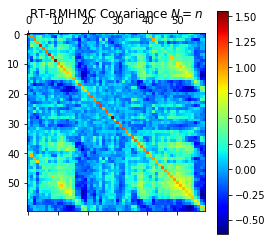

In [27]:
print(U(x_init))
plt.matshow(f(x_init),cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N=n$')
plt.show()
#4 before

In [28]:
print(U(x_init))
t1 = time.time()
p1 = potential_derv_fast(x_init)
t2 = time.time()
p2 = Potential_approx_deriv(x_init,0.000000001)
t3 = time.time()
print('sup|grad_exact - grad_num| =',max(p2-p1))
print('Exact time = ',t2-t1)
print('Numerical time = ',t3-t2)

403.52293251964176
sup|grad_exact - grad_num| = 0.004531759403409996
Exact time =  0.06287336349487305
Numerical time =  1.1601643562316895


4) Simulation

In [29]:
#Initialise
T = 0.01
num_of_events = 3
dt = 0.001

In [30]:
@numba.jit(nopython=True)
def RRHMC(num_of_events,dt_max,T,x_init):
    
    #Exponential Expected Value
    rate = T
    x = x_init
    
    position_list = [x_init]
    v = tangent_space_gaussian(x)
    
    accept = 0.
    gradient_evaluations = 0
    
    for i in range(num_of_events):
        
        t = time_exp(rate)
        L = np.ceil(t/dt_max)
        
        dt = t/L
        
        h = hamiltonian(x,v)
    
        xnew,vnew = RATTLE_with_Potential(x,v,t,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #adding in rejection for non-positive diagonal matrices.
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
            

        
        position_list.append(x)
        
        v = tangent_space_gaussian(x)
        if i%10==0:
            print(i)
        
        
    return position_list

In [31]:
@numba.jit(nopython=True)
def RHMC(num_of_events,dt,T,x_init):
    
#     x = list(matrix_to_vec(np.eye(d,p)))
#     x += list(np.ones(d + p))
    x = x_init
    #initialisation of x on V_{d,p} \times \mathbb{R}^p 
    #                        \times \mathbb{R}^d
    v = tangent_space_gaussian(x)
    
    position_list = [x]
    
    
    for i in range(num_of_events):
        
        h = hamiltonian(x,v)
        
        xnew,vnew = RATTLE_with_Potential(x,v,T,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #with reject with positivity constraint
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
        
        position_list.append(x)
        v = tangent_space_gaussian(x)  
        if i%10==0:
            print(i)
            
    return position_list

In [32]:
t = time.time()
position = RRHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('RT time =',elapsed)
t = time.time()
position = RHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('DT time =',elapsed)

0
RT time = 6.8765270709991455
0
DT time = 6.430796146392822


# Check

In [35]:
#Initialise
#T = 0.1
num_of_events = 50000
dt = 0.00005
N = 10
T = N*dt
#ensure positivity
#log normal prior

In [36]:
position = RRHMC(num_of_events,dt,T,x_init)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990
1000
1010
1020
1030
1040
1050
1060
1070
1080
1090
1100
1110
1120
1130
1140
1150
1160
1170
1180
1190
1200
1210
1220
1230
1240
1250
1260
1270
1280
1290
1300
1310
1320
1330
1340
1350
1360
1370
1380
1390
1400
1410
1420
1430
1440
1450
1460
1470
1480
1490
1500
1510
1520
1530
1540
1550
1560
1570
1580
1590
1600
1610
1620
1630
1640
1650
1660
1670
1680
1690
1700
1710
1720
1730
1740
1750
1760
1770
1780
1790
1800
1810
1820
1830
1840
1850
1860
1870
1880
1890
1900
1910
1920
1930
1940
1950
1960
1970
1980
1990
2000
2010
2020
2030
2040
2050
2060
2070
2080
2090
2100
2110
2120
2130
2140
2150
2160
2170
2180
2190
2200
2210
2

15510
15520
15530
15540
15550
15560
15570
15580
15590
15600
15610
15620
15630
15640
15650
15660
15670
15680
15690
15700
15710
15720
15730
15740
15750
15760
15770
15780
15790
15800
15810
15820
15830
15840
15850
15860
15870
15880
15890
15900
15910
15920
15930
15940
15950
15960
15970
15980
15990
16000
16010
16020
16030
16040
16050
16060
16070
16080
16090
16100
16110
16120
16130
16140
16150
16160
16170
16180
16190
16200
16210
16220
16230
16240
16250
16260
16270
16280
16290
16300
16310
16320
16330
16340
16350
16360
16370
16380
16390
16400
16410
16420
16430
16440
16450
16460
16470
16480
16490
16500
16510
16520
16530
16540
16550
16560
16570
16580
16590
16600
16610
16620
16630
16640
16650
16660
16670
16680
16690
16700
16710
16720
16730
16740
16750
16760
16770
16780
16790
16800
16810
16820
16830
16840
16850
16860
16870
16880
16890
16900
16910
16920
16930
16940
16950
16960
16970
16980
16990
17000
17010
17020
17030
17040
17050
17060
17070
17080
17090
17100
17110
17120
17130
17140
17150
17160
1717

29170
29180
29190
29200
29210
29220
29230
29240
29250
29260
29270
29280
29290
29300
29310
29320
29330
29340
29350
29360
29370
29380
29390
29400
29410
29420
29430
29440
29450
29460
29470
29480
29490
29500
29510
29520
29530
29540
29550
29560
29570
29580
29590
29600
29610
29620
29630
29640
29650
29660
29670
29680
29690
29700
29710
29720
29730
29740
29750
29760
29770
29780
29790
29800
29810
29820
29830
29840
29850
29860
29870
29880
29890
29900
29910
29920
29930
29940
29950
29960
29970
29980
29990
30000
30010
30020
30030
30040
30050
30060
30070
30080
30090
30100
30110
30120
30130
30140
30150
30160
30170
30180
30190
30200
30210
30220
30230
30240
30250
30260
30270
30280
30290
30300
30310
30320
30330
30340
30350
30360
30370
30380
30390
30400
30410
30420
30430
30440
30450
30460
30470
30480
30490
30500
30510
30520
30530
30540
30550
30560
30570
30580
30590
30600
30610
30620
30630
30640
30650
30660
30670
30680
30690
30700
30710
30720
30730
30740
30750
30760
30770
30780
30790
30800
30810
30820
3083

42830
42840
42850
42860
42870
42880
42890
42900
42910
42920
42930
42940
42950
42960
42970
42980
42990
43000
43010
43020
43030
43040
43050
43060
43070
43080
43090
43100
43110
43120
43130
43140
43150
43160
43170
43180
43190
43200
43210
43220
43230
43240
43250
43260
43270
43280
43290
43300
43310
43320
43330
43340
43350
43360
43370
43380
43390
43400
43410
43420
43430
43440
43450
43460
43470
43480
43490
43500
43510
43520
43530
43540
43550
43560
43570
43580
43590
43600
43610
43620
43630
43640
43650
43660
43670
43680
43690
43700
43710
43720
43730
43740
43750
43760
43770
43780
43790
43800
43810
43820
43830
43840
43850
43860
43870
43880
43890
43900
43910
43920
43930
43940
43950
43960
43970
43980
43990
44000
44010
44020
44030
44040
44050
44060
44070
44080
44090
44100
44110
44120
44130
44140
44150
44160
44170
44180
44190
44200
44210
44220
44230
44240
44250
44260
44270
44280
44290
44300
44310
44320
44330
44340
44350
44360
44370
44380
44390
44400
44410
44420
44430
44440
44450
44460
44470
44480
4449

In [37]:
first_entry_list = []
first = 0
burn = 25000
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    q = U(position[i+burn])
    first += q
    if q<=640:
        print(i)
    first_entry_list.append(first/(i+1))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060
2061
2062
2063
2064
2065
2066
2067
2068
2069
2070
2071
2072
2073
2074
2075
2076
2077
2078
2079
2080
2081
2082
2083
2084
2085
2086
2087
2088
2089
2090
2091
2092
2093
2094
2095
2096
2097
2098
2099
2100
2101
2102
2103
2104
2105
2106
2107
2108
2109
2110
2111
2112
2113
2114
2115
2116
2117
2118
2119
2120
2121
2122
2123
2124
2125
2126
2127
2128
2129
2130
2131
2132
2133
2134
2135
2136


3627
3628
3629
3630
3631
3632
3633
3634
3635
3636
3637
3638
3639
3640
3641
3642
3643
3644
3645
3646
3647
3648
3649
3650
3651
3652
3653
3654
3655
3656
3657
3658
3659
3660
3661
3662
3663
3664
3665
3666
3667
3668
3669
3670
3671
3672
3673
3674
3675
3676
3677
3678
3679
3680
3681
3682
3683
3684
3685
3686
3687
3688
3689
3690
3691
3692
3693
3694
3695
3696
3697
3698
3699
3700
3701
3702
3703
3704
3705
3706
3707
3708
3709
3710
3711
3712
3713
3714
3715
3716
3717
3718
3719
3720
3721
3722
3723
3724
3725
3726
3727
3728
3729
3730
3731
3732
3733
3734
3735
3736
3737
3738
3739
3740
3741
3742
3743
3744
3745
3746
3747
3748
3749
3750
3751
3752
3753
3754
3755
3756
3757
3758
3759
3760
3761
3762
3763
3764
3765
3766
3767
3768
3769
3770
3771
3772
3773
3774
3775
3776
3777
3778
3779
3780
3781
3782
3783
3784
3785
3786
3787
3788
3789
3790
3791
3792
3793
3794
3795
3796
3797
3798
3799
3800
3801
3802
3803
3804
3805
3806
3807
3808
3809
3810
3811
3812
3813
3814
3815
3816
3817
3818
3819
3820
3821
3822
3823
3824
3825
3826


5282
5283
5284
5285
5286
5287
5288
5289
5290
5291
5292
5293
5294
5295
5296
5297
5298
5299
5300
5301
5302
5303
5304
5305
5306
5307
5308
5309
5310
5311
5312
5313
5314
5315
5316
5317
5318
5319
5320
5321
5322
5323
5324
5325
5326
5327
5328
5329
5330
5331
5332
5333
5334
5335
5336
5337
5338
5339
5340
5341
5342
5343
5344
5345
5346
5347
5348
5349
5350
5351
5352
5353
5354
5355
5356
5357
5358
5359
5360
5361
5362
5363
5364
5365
5366
5367
5368
5369
5370
5371
5372
5373
5374
5375
5376
5377
5378
5379
5380
5381
5382
5383
5384
5385
5386
5387
5388
5389
5390
5391
5392
5393
5394
5395
5396
5397
5398
5399
5400
5401
5402
5403
5404
5405
5406
5407
5408
5409
5410
5411
5412
5413
5414
5415
5416
5417
5418
5419
5420
5421
5422
5423
5424
5425
5426
5427
5428
5429
5430
5431
5432
5433
5434
5435
5436
5437
5438
5439
5440
5441
5442
5443
5444
5445
5446
5447
5448
5449
5450
5451
5452
5453
5454
5455
5456
5457
5458
5459
5460
5461
5462
5463
5464
5465
5466
5467
5468
5469
5470
5471
5472
5473
5474
5475
5476
5477
5478
5479
5480
5481


6932
6933
6934
6935
6936
6937
6938
6939
6940
6941
6942
6943
6944
6945
6946
6947
6948
6949
6950
6951
6952
6953
6954
6955
6956
6957
6958
6959
6960
6961
6962
6963
6964
6965
6966
6967
6968
6969
6970
6971
6972
6973
6974
6975
6976
6977
6978
6979
6980
6981
6982
6983
6984
6985
6986
6987
6988
6989
6990
6991
6992
6993
6994
6995
6996
6997
6998
6999
7000
7001
7002
7003
7004
7005
7006
7007
7008
7009
7010
7011
7012
7013
7014
7015
7016
7017
7018
7019
7020
7021
7022
7023
7024
7025
7026
7027
7028
7029
7030
7031
7032
7033
7034
7035
7036
7037
7038
7039
7040
7041
7042
7043
7044
7045
7046
7047
7048
7049
7050
7051
7052
7053
7054
7055
7056
7057
7058
7059
7060
7061
7062
7063
7064
7065
7066
7067
7068
7069
7070
7071
7072
7073
7074
7075
7076
7077
7078
7079
7080
7081
7082
7083
7084
7085
7086
7087
7088
7089
7090
7091
7092
7093
7094
7095
7096
7097
7098
7099
7100
7101
7102
7103
7104
7105
7106
7107
7108
7109
7110
7111
7112
7113
7114
7115
7116
7117
7118
7119
7120
7121
7122
7123
7124
7125
7126
7127
7128
7129
7130
7131


...

18653
18654
18655
18656
18657
18658
18659
18660
18661
18662
18663
18664
18665
18666
18667
18668
18669
18670
18671
18672
18673
18674
18675
18676
18677
18678
18679
18680
18681
18682
18683
18684
18685
18686
18687
18688
18689
18690
18691
18692
18693
18694
18695
18696
18697
18698
18699
18700
18701
18702
18703
18704
18705
18706
18707
18708
18709
18710
18711
18712
18713
18714
18715
18716
18717
18718
18719
18720
18721
18722
18723
18724
18725
18726
18727
18728
18729
18730
18731
18732
18733
18734
18735
18736
18737
18738
18739
18740
18741
18742
18743
18744
18745
18746
18747
18748
18749
18750
18751
18752
18753
18754
18755
18756
18757
18758
18759
18760
18761
18762
18763
18764
18765
18766
18767
18768
18769
18770
18771
18772
18773
18774
18775
18776
18777
18778
18779
18780
18781
18782
18783
18784
18785
18786
18787
18788
18789
18790
18791
18792
18793
18794
18795
18796
18797
18798
18799
18800
18801
18802
18803
18804
18805
18806
18807
18808
18809
18810
18811
18812
18813
18814
18815
18816
18817
18818
1881

20067
20068
20069
20070
20071
20072
20073
20074
20075
20076
20077
20078
20079
20080
20081
20082
20083
20084
20085
20086
20087
20088
20089
20090
20091
20092
20093
20094
20095
20096
20097
20098
20099
20100
20101
20102
20103
20104
20105
20106
20107
20108
20109
20110
20111
20112
20113
20114
20115
20116
20117
20118
20119
20120
20121
20122
20123
20124
20125
20126
20127
20128
20129
20130
20131
20132
20133
20134
20135
20136
20137
20138
20139
20140
20141
20142
20143
20144
20145
20146
20147
20148
20149
20150
20151
20152
20153
20154
20155
20156
20157
20158
20159
20160
20161
20162
20163
20164
20165
20166
20167
20168
20169
20170
20171
20172
20173
20174
20175
20176
20177
20178
20179
20180
20181
20182
20183
20184
20185
20186
20187
20188
20189
20190
20191
20192
20193
20194
20195
20196
20197
20198
20199
20200
20201
20202
20203
20204
20205
20206
20207
20208
20209
20210
20211
20212
20213
20214
20215
20216
20217
20218
20219
20220
20221
20222
20223
20224
20225
20226
20227
20228
20229
20230
20231
20232
2023

21455
21456
21457
21458
21459
21460
21461
21462
21463
21464
21465
21466
21467
21468
21469
21470
21471
21472
21473
21474
21475
21476
21477
21478
21479
21480
21481
21482
21483
21484
21485
21486
21487
21488
21489
21490
21491
21492
21493
21494
21495
21496
21497
21498
21499
21500
21501
21502
21503
21504
21505
21506
21507
21508
21509
21510
21511
21512
21513
21514
21515
21516
21517
21518
21519
21520
21521
21522
21523
21524
21525
21526
21527
21528
21529
21530
21531
21532
21533
21534
21535
21536
21537
21538
21539
21540
21541
21542
21543
21544
21545
21546
21547
21548
21549
21550
21551
21552
21553
21554
21555
21556
21557
21558
21559
21560
21561
21562
21563
21564
21565
21566
21567
21568
21569
21570
21571
21572
21573
21574
21575
21576
21577
21578
21579
21580
21581
21582
21583
21584
21585
21586
21587
21588
21589
21590
21591
21592
21593
21594
21595
21596
21597
21598
21599
21600
21601
21602
21603
21604
21605
21606
21607
21608
21609
21610
21611
21612
21613
21614
21615
21616
21617
21618
21619
21620
2162

22822
22823
22824
22825
22826
22827
22828
22829
22830
22831
22832
22833
22834
22835
22836
22837
22838
22839
22840
22841
22842
22843
22844
22845
22846
22847
22848
22849
22850
22851
22852
22853
22854
22855
22856
22857
22858
22859
22860
22861
22862
22863
22864
22865
22866
22867
22868
22869
22870
22871
22872
22873
22874
22875
22876
22877
22878
22879
22880
22881
22882
22883
22884
22885
22886
22887
22888
22889
22890
22891
22892
22893
22894
22895
22896
22897
22898
22899
22900
22901
22902
22903
22904
22905
22906
22907
22908
22909
22910
22911
22912
22913
22914
22915
22916
22917
22918
22919
22920
22921
22922
22923
22924
22925
22926
22927
22928
22929
22930
22931
22932
22933
22934
22935
22936
22937
22938
22939
22940
22941
22942
22943
22944
22945
22946
22947
22948
22949
22950
22951
22952
22953
22954
22955
22956
22957
22958
22959
22960
22961
22962
22963
22964
22965
22966
22967
22968
22969
22970
22971
22972
22973
22974
22975
22976
22977
22978
22979
22980
22981
22982
22983
22984
22985
22986
22987
2298

24240
24241
24242
24243
24244
24245
24246
24247
24248
24249
24250
24251
24252
24253
24254
24255
24256
24257
24258
24259
24260
24261
24262
24263
24264
24265
24266
24267
24268
24269
24270
24271
24272
24273
24274
24275
24276
24277
24278
24279
24280
24281
24282
24283
24284
24285
24286
24287
24288
24289
24290
24291
24292
24293
24294
24295
24296
24297
24298
24299
24300
24301
24302
24303
24304
24305
24306
24307
24308
24309
24310
24311
24312
24313
24314
24315
24316
24317
24318
24319
24320
24321
24322
24323
24324
24325
24326
24327
24328
24329
24330
24331
24332
24333
24334
24335
24336
24337
24338
24339
24340
24341
24342
24343
24344
24345
24346
24347
24348
24349
24350
24351
24352
24353
24354
24355
24356
24357
24358
24359
24360
24361
24362
24363
24364
24365
24366
24367
24368
24369
24370
24371
24372
24373
24374
24375
24376
24377
24378
24379
24380
24381
24382
24383
24384
24385
24386
24387
24388
24389
24390
24391
24392
24393
24394
24395
24396
24397
24398
24399
24400
24401
24402
24403
24404
24405
2440

Text(0.5, 0, 'number of samples')

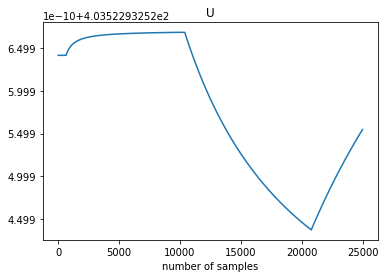

In [38]:
plt.plot(first_entry_list)
plt.title('U')
plt.xlabel('number of samples')

In [39]:
#trace plots

In [40]:
last_entry_list = []
last = 0
burn = 10000
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    last += mat[0,-1]
    last_entry_list.append(last/(i+1))

Text(0.5, 0, 'number of samples')

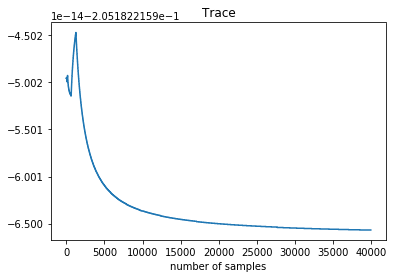

In [41]:
plt.plot(last_entry_list)
plt.title('Trace')
plt.xlabel('number of samples')

In [42]:
burn = 10000
Σ_ave = np.zeros((d,d))
for i in range(num_of_events-burn):
    Σ_ave += f(position[i+burn])/(num_of_events-burn)
    #print(len(position[i+burn]))

In [43]:
S = Σ_ave
print(S)

[[ 1.55710678  0.05540231 -0.13422964 ...  0.03607689 -0.20723472
  -0.20518222]
 [ 0.05540231  1.05195642  0.05892434 ...  0.02290577 -0.01165888
  -0.14350778]
 [-0.13422964  0.05892434  1.09840818 ... -0.28949015  0.0791113
   0.09898321]
 ...
 [ 0.03607689  0.02290577 -0.28949015 ...  0.82774387  0.04206763
  -0.11906336]
 [-0.20723472 -0.01165888  0.0791113  ...  0.04206763  0.86779634
   0.41436795]
 [-0.20518222 -0.14350778  0.09898321 ... -0.11906336  0.41436795
   0.91877917]]


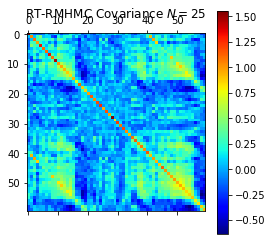

In [44]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N = 25$')
plt.show()
#4 before
#plot increase in maximum element

In [45]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

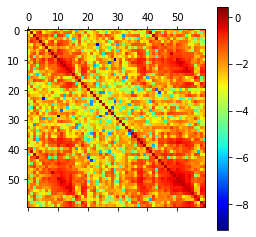

In [46]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [47]:
S_inv = np.linalg.inv(S)

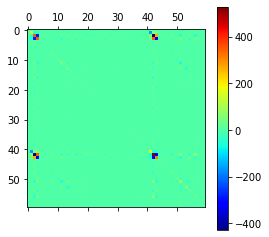

In [48]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [49]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

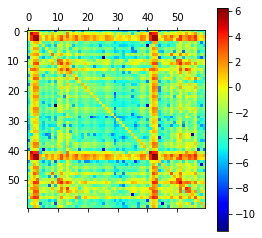

In [50]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# True Covariance Matrix

In [51]:
mean1 = np.zeros(d)
for i in range(2000):
    mean1 += Data[:,i]/2000

In [52]:
S = np.zeros((d,d))
for i in range(2000):
    x = Data[:,i] - mean1
    S += np.outer(x,x)/2000

In [53]:
print(S[-1,-1])
print(S[0,0])

0.6447390119301307
1.4691111914379598


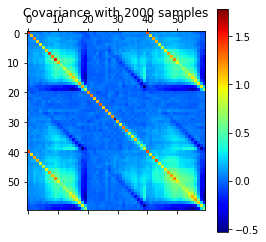

In [54]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('Covariance with 2000 samples')
plt.show()

In [55]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

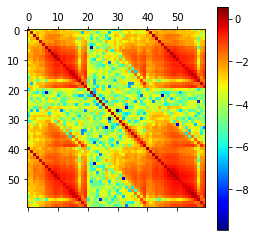

In [56]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [57]:
S_inv = np.linalg.inv(S)

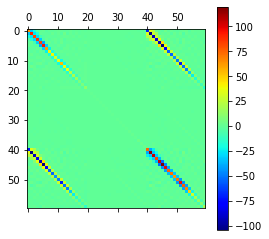

In [58]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [59]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

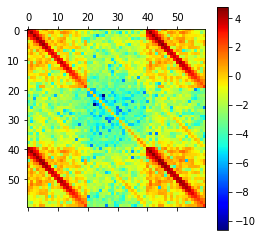

In [60]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# Using n points

In [61]:
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n

In [62]:
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

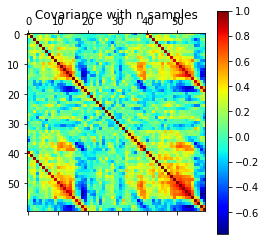

In [63]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [64]:
#print(list(np.diag(S)))

In [65]:
#print(list(position[-1][:d*p]))

In [66]:
#print(list(position[-1]))

In [67]:
#np.trace(S)

In [68]:
#print(list(position[-1]))

In [69]:
S_True = S#*np.outer(np.sqrt(var),np.sqrt(var))

In [70]:
Σ_est = Σ_ave#*np.outer(np.sqrt(var),np.sqrt(var))

In [71]:
small_S = S_small#*np.outer(np.sqrt(var),np.sqrt(var))

In [72]:
np.linalg.norm(S_True - Σ_est,'fro')/np.linalg.norm(S_True)

0.6076082644857967

In [73]:
np.linalg.norm(S_True - small_S,'fro')/np.linalg.norm(S_True)

0.6570254189115307

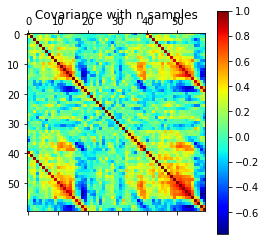

In [74]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [75]:
True_S = S_True*np.outer(np.sqrt(var),np.sqrt(var))

In [76]:
Σ_est = Σ_ave*np.outer(np.sqrt(var),np.sqrt(var))

In [77]:
small_S = S_small*np.outer(np.sqrt(var),np.sqrt(var))

In [78]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

0.49465397817914464

In [79]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

0.4010586481746751

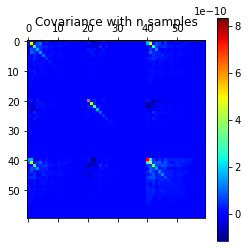

In [80]:
plt.matshow(Σ_est,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

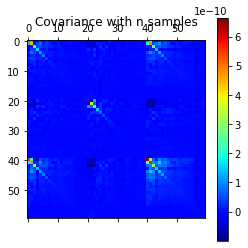

In [81]:
plt.matshow(small_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

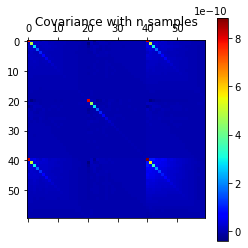

In [82]:
plt.matshow(True_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [83]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

0.49465397817914464

In [84]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

0.4010586481746751

In [85]:
# plt.matshow(True_S-Σ_est,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

In [86]:
# plt.matshow(True_S-small_S,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

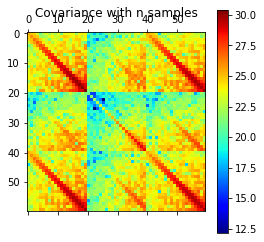

In [87]:
plt.matshow(np.log(abs(np.linalg.inv(True_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

403.52293251964176


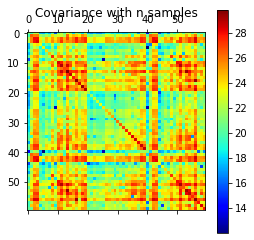

In [88]:
print(U(position[7500]))
plt.matshow(np.log(abs(np.linalg.inv(Σ_est))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

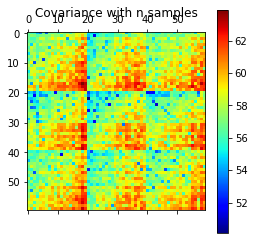

In [89]:
plt.matshow(np.log(abs(np.linalg.inv(small_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [90]:
log_S = np.log(abs(np.linalg.inv(True_S)))

In [91]:
log_Σ = np.log(abs(np.linalg.inv(Σ_est))) 

In [92]:
log_small = np.log(abs(np.linalg.inv(small_S)))

In [93]:
np.linalg.norm(log_S - log_Σ,'fro')/np.linalg.norm(log_S)

0.11067772823032745

In [94]:
np.linalg.norm(log_S - log_small,'fro')/np.linalg.norm(log_S)

1.4714324293518886